# SH Coloring Playground (Manual Gaussian Params)

This notebook manually builds `gaussian_params` and feeds them to `self.renderer.render()` so you can understand how SH values affect renders.

What this notebook gives you:
- A non-symmetric 3D pyramid layout for Gaussian centers
- Baseline render from manually chosen Gaussian params
- Controlled SH experiments (DC and first-order terms)
- Sanity checks for parameter correctness (shape/range/normalization)

In [1]:
import os
import sys
from pathlib import Path

import torch
import matplotlib.pyplot as plt

project_root = Path.cwd()
if not (project_root / 'src').exists():
    raise RuntimeError(f'Run this notebook from the project root. Current: {project_root}')

sys.path.insert(0, str(project_root / 'src'))

# Use degree-1 SH config for easier interpretation
os.environ['NLFGS_CONFIG'] = str(project_root / 'configs' / 'nlfgs_gpu.yaml')

from avatar_utils.config import load_config, get_config
cfg = load_config(os.environ['NLFGS_CONFIG'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('SH degree from config:', get_config().get('decoder', {}).get('sh_degree'))
print('Image size:', get_config().get('data', {}).get('image_size'))

Device: cuda
SH degree from config: 1
Image size: [512, 512]


In [2]:
from render.gaussian_renderer import GsplatRenderer

class RenderHarness:
    def __init__(self):
        self.renderer = GsplatRenderer()

    @torch.no_grad()
    def render(self, gaussian_3d, gaussian_params, view_names):
        return self.renderer.render(
            gaussian_3d=gaussian_3d,
            gaussian_params=gaussian_params,
            view_name=view_names,
        )

harness = RenderHarness()
views = ['front', 'left', 'right', 'back']

print('Renderer SH degree:', harness.renderer.sh_degree)
num_sh_coeff = (harness.renderer.sh_degree + 1) ** 2
print('SH coeffs per color channel:', num_sh_coeff)
print('Total SH dims expected:', num_sh_coeff * 3)

Renderer SH degree: 1
SH coeffs per color channel: 4
Total SH dims expected: 12


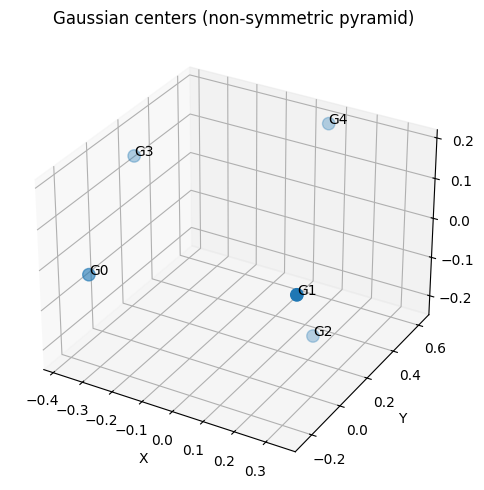

In [3]:
# Non-symmetric pyramid (5 Gaussians):
# 4 base corners + 1 off-center apex
gaussian_3d = torch.tensor([
    [-0.30, -0.25,  0.00],  # base A
    [ 0.34, -0.20,  0.08],  # base B
    [ 0.18,  0.28, -0.22],  # base C
    [-0.38,  0.20,  0.14],  # base D
    [ 0.07,  0.62,  0.19],  # apex (intentionally off-center)
], dtype=torch.float32, device=device)

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gaussian_3d[:, 0].cpu(), gaussian_3d[:, 1].cpu(), gaussian_3d[:, 2].cpu(), s=80)
for i, p in enumerate(gaussian_3d.cpu()):
    ax.text(p[0], p[1], p[2], f'G{i}')
ax.set_title('Gaussian centers (non-symmetric pyramid)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.tight_layout()
plt.show()

In [ ]:
def build_gaussian_params(
    gaussian_3d,
    sh_degree,
    base_rgb=(0.9, 0.9, 0.9),
    alpha=0.95,
    scale=0.055,
    l1_rgb=(0.0, 0.0, 0.0),
    l2_rgb=(0.0, 0.0, 0.0),
    l3_rgb=(0.0, 0.0, 0.0),
):
    """
    Returns dict with keys: scales, rotation, alpha, sh.
    SH layout is packed as (N, coeff_count*3), where reshaped view is (N, coeff_count, 3).
    coeff index 0 = DC term; index 1.. are higher-order terms.
    """
    n = gaussian_3d.shape[0]
    coeff_count = (sh_degree + 1) ** 2

    scales = torch.full((n, 3), float(scale), dtype=torch.float32, device=gaussian_3d.device)

    rotation = torch.zeros((n, 4), dtype=torch.float32, device=gaussian_3d.device)
    rotation[:, 0] = 1.0  # identity quaternion [w, x, y, z]

    alpha_t = torch.full((n,), float(alpha), dtype=torch.float32, device=gaussian_3d.device)

    sh = torch.zeros((n, coeff_count, 3), dtype=torch.float32, device=gaussian_3d.device)
    sh[:, 0, :] = torch.tensor(base_rgb, dtype=torch.float32, device=gaussian_3d.device)

    # For degree >= 1, set first non-DC coefficient (index 1) to inspect direction-dependent color changes
    if coeff_count > 1:
        sh[:, 1, :] = torch.tensor(l1_rgb, dtype=torch.float32, device=gaussian_3d.device)
        sh[:, 2, :] = torch.tensor(l2_rgb, dtype=torch.float32, device=gaussian_3d.device)
        sh[:, 3, :] = torch.tensor(l3_rgb, dtype=torch.float32, device=gaussian_3d.device)

    sh = sh.reshape(n, coeff_count * 3)
    
    print(sh)

    return {
        'scales': scales,
        'rotation': rotation,
        'alpha': alpha_t,
        'sh': sh,
    }

def validate_gaussian_params(gaussian_3d, gaussian_params, sh_degree):
    n = gaussian_3d.shape[0]
    expected_sh = (sh_degree + 1) ** 2 * 3

    assert gaussian_params['scales'].shape == (n, 3), f"scales shape mismatch: {gaussian_params['scales'].shape}"
    assert gaussian_params['rotation'].shape == (n, 4), f"rotation shape mismatch: {gaussian_params['rotation'].shape}"
    assert gaussian_params['alpha'].shape == (n,), f"alpha shape mismatch: {gaussian_params['alpha'].shape}"
    assert gaussian_params['sh'].shape == (n, expected_sh), f"sh shape mismatch: {gaussian_params['sh'].shape}"

    rot_norm = torch.linalg.norm(gaussian_params['rotation'], dim=-1)
    assert torch.allclose(rot_norm, torch.ones_like(rot_norm), atol=1e-5), 'rotation quaternions are not normalized'

    assert torch.all(gaussian_params['scales'] > 0), 'scales must be > 0'
    assert torch.all((gaussian_params['alpha'] >= 0) & (gaussian_params['alpha'] <= 1)), 'alpha must be in [0,1]'

    for k, v in gaussian_params.items():
        assert torch.isfinite(v).all(), f'{k} contains non-finite values'

    print('✅ gaussian_params shape/range checks passed')

def show_render_grid(images_bhwc, view_names, title):
    b = images_bhwc.shape[0]
    fig, axes = plt.subplots(1, b, figsize=(4 * b, 4))
    if b == 1:
        axes = [axes]

    for i in range(b):
        img = images_bhwc[i].detach().float().cpu().clamp(0, 1)
        axes[i].imshow(img)
        axes[i].set_title(view_names[i])
        axes[i].axis('off')

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

tensor([[1., 1., 1., 1., 2., 3., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 2., 3., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 2., 3., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 2., 3., 0., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 2., 3., 0., 0., 0., 0., 0., 0.]], device='cuda:0')
✅ gaussian_params shape/range checks passed
Rendered shape: (4, 512, 512, 3)


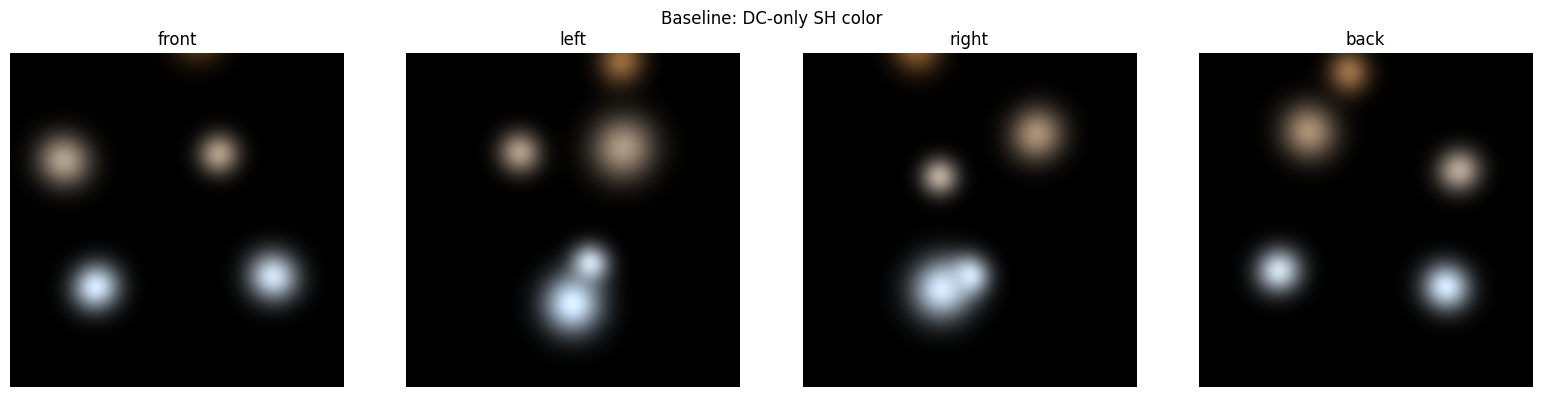

In [ ]:
# Baseline render
params_baseline = build_gaussian_params(
    gaussian_3d=gaussian_3d,
    sh_degree=harness.renderer.sh_degree,
    base_rgb=(1., 1., 1.0),
    alpha=0.98,
    scale=0.06,
    l1_rgb=(1.0, 2.0, 3.0),
    l2_rgb=(0.0, 0.0, 0.0),
    l3_rgb=(0.0, 0.0, 0.0)
)
validate_gaussian_params(gaussian_3d, params_baseline, harness.renderer.sh_degree)

imgs_baseline = harness.render(gaussian_3d, params_baseline, views)
print('Rendered shape:', tuple(imgs_baseline.shape))
show_render_grid(imgs_baseline, views, 'Baseline: DC-only SH color')

In [ ]:
# Experiment 1: Sweep only DC coefficient (uniform base color)
dc_presets = [
    ('dark gray', (0.20, 0.20, 0.20)),
    ('red',       (0.85, 0.20, 0.20)),
    ('green',     (0.20, 0.85, 0.20)),
    ('blue',      (0.20, 0.20, 0.85)),
]

for label, rgb in dc_presets:
    params = build_gaussian_params(
        gaussian_3d=gaussian_3d,
        sh_degree=harness.renderer.sh_degree,
        base_rgb=rgb,
        alpha=0.98,
        scale=0.06,
        l1_rgb=(0.0, 0.0, 0.0),
    )
    imgs = harness.render(gaussian_3d, params, views)
    show_render_grid(imgs, views, f'DC sweep: {label} {rgb}')

In [ ]:
# Experiment 2: Keep DC fixed, vary first non-DC SH coefficient (index 1)
# This is intended to reveal view-dependent color changes.
l1_values = [-0.8, -0.4, 0.0, 0.4, 0.8]

if (harness.renderer.sh_degree + 1) ** 2 <= 1:
    print('Current SH degree has no non-DC coefficients to sweep.')
else:
    for v in l1_values:
        params = build_gaussian_params(
            gaussian_3d=gaussian_3d,
            sh_degree=harness.renderer.sh_degree,
            base_rgb=(0.55, 0.55, 0.55),
            alpha=0.98,
            scale=0.06,
            l1_rgb=(v, 0.0, 0.0),  # affect red channel only
        )
        imgs = harness.render(gaussian_3d, params, views)
        show_render_grid(imgs, views, f'L1 coeff sweep (index 1, red): {v:+.2f}')

In [ ]:
# Experiment 3: Verify that renderer catches SH shape mismatches
params_bad = build_gaussian_params(
    gaussian_3d=gaussian_3d,
    sh_degree=harness.renderer.sh_degree,
    base_rgb=(0.8, 0.8, 0.2),
    alpha=0.98,
    scale=0.06,
)

# Remove one column from SH to trigger expected assertion
params_bad['sh'] = params_bad['sh'][:, :-1]

try:
    _ = harness.render(gaussian_3d, params_bad, ['front'])
except AssertionError as e:
    print('✅ Expected renderer assertion triggered:')
    print(e)

## How to interpret quickly

- **DC term only (coeff 0):** mostly controls the global/base color.
- **Non-DC terms (coeff 1+):** introduce view-dependent color variation.
- If output clips (too bright/saturated), reduce coefficient magnitudes.
- Start simple: tune `base_rgb`, then adjust one non-DC coefficient at a time.

Tip: duplicate the sweep cell and vary one channel or coefficient index per run for clean intuition.